In [40]:
from pathlib import Path

OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved to:", OUT_DIR.resolve())

Outputs will be saved to: C:\Users\donna\Documents\Python Scripts\JupyterProjects\outputs


In [41]:
import pandas as pd
import re
from datetime import datetime

# [SYNTHETIC] input path for synthetic data
IN_PATH = "synthetic_data/sample_posts_2000.csv"
df = pd.read_csv(IN_PATH)

# [REPORT] original report uses df["content"] and df["timeofposting"] columns
# [SYNTHETIC] we only have post_text; we keep naming consistent by creating "content"
df["content"] = df["post_text"]
df["index"] = df["post_id"]  # keep an index-like column, similar to report

df.head(5)

,post_id,post_text,content,index
0,1,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,1
1,2,#ride11302025 Need a ride Sac-Fremont. Budget ...,#ride11302025 Need a ride Sac-Fremont. Budget ...,2
2,3,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,3
3,4,#drive08252025 #drive09012025 Need a drive Sac...,#drive08252025 #drive09012025 Need a drive Sac...,4
4,5,#drive01232024 #drive01252024 Need a driev Pal...,#drive01232024 #drive01252024 Need a driev Pal...,5


In [42]:
# [REPORT] create df2 with same columns & extra parsed columns
df2 = pd.DataFrame(index=range(len(df)), columns=range(len(df.columns)))
df2.columns = df.columns

df2["index"] = df["index"]
df2["content"] = df["content"]

# [REPORT] in report they also keep timeofposting; synthetic doesn't have it
# [SYNTHETIC] create placeholder (optional)
df2["timeofposting"] = None

# [REPORT] parsed targets
df2["rideordrive"] = ""   # report: driver vs rider indicator
df2["dateofride"] = ""    # report: take first hashtag if multiple
df2["weekdayofride"] = "" # report: derived from dateofride
df2["price"] = 0          # report: 0 if missing / rider post

df2.head(3)


,post_id,post_text,content,index,timeofposting,rideordrive,dateofride,weekdayofride,price
0,NaN,NaN,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,1,None,,,,0
1,NaN,NaN,#ride11302025 Need a ride Sac-Fremont. Budget ...,2,None,,,,0
2,NaN,NaN,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,3,None,,,,0


In [43]:
# [REPORT] finds all occurrence of # in string and add empty space in front of it
def hashtag(word):
    idx = []
    for i, ch in enumerate(word):
        if ch == "#":
            idx.append(i)
    # insert spaces from back to front to avoid shifting indices
    for i in reversed(idx):
        word = word[:i] + " " + word[i:]
    return word

# [REPORT] weekday mapping function
def find_weekday(dte):
    weekdays = dte.weekday()  # Mon=0
    if weekdays == 0:
        return "Monday"
    elif weekdays == 1:
        return "Tuesday"
    elif weekdays == 2:
        return "Wednesday"
    elif weekdays == 3:
        return "Thursday"
    elif weekdays == 4:
        return "Friday"
    elif weekdays == 5:
        return "Saturday"
    else:
        return "Sunday"


In [44]:
# [REPORT] loop over each post (report used SettingWithCopyWarning style writes)
# [SYNTHETIC] we keep same logic but use .at to avoid warnings

for i in range(len(df2)):
    text = df2.at[i, "content"]
    if not isinstance(text, str):
        df2.at[i, "rideordrive"] = None
        df2.at[i, "dateofride"] = None
        df2.at[i, "weekdayofride"] = None
        continue

    w = hashtag(text.lower())
    parts = w.split()

    # collect hashtags tokens like "#ride03182022"
    tags = [p for p in parts if p.startswith("#ride") or p.startswith("#drive")]

    # [REPORT] if multiple hashtags, take the first
    if len(tags) == 0:
        df2.at[i, "rideordrive"] = None
        df2.at[i, "dateofride"] = None
        df2.at[i, "weekdayofride"] = None
        continue

    tag = tags[0]  # first hashtag

    # [REPORT] rideordrive indicator: report examples show drive=0, ride=1
    if tag.startswith("#drive"):
        df2.at[i, "rideordrive"] = 0
        date_raw = tag.replace("#drive", "")
    else:
        df2.at[i, "rideordrive"] = 1
        date_raw = tag.replace("#ride", "")

    # [REPORT] clean date_raw:
    # if mmddyy (len==6) => insert "20"
    # if >8 => truncate
    date_raw = re.sub(r"[^0-9]", "", date_raw)  # [SYNTHETIC] safety: keep digits only

    if len(date_raw) == 6:
        date_raw = date_raw[:4] + "20" + date_raw[4:]
    if len(date_raw) > 8:
        date_raw = date_raw[:8]

    # parse
    try:
        dte = datetime.strptime(date_raw, "%m%d%Y")
        df2.at[i, "dateofride"] = dte.strftime("%Y-%m-%d")  # report stored yyyy-mm-dd
        df2.at[i, "weekdayofride"] = find_weekday(dte)
    except Exception:
        df2.at[i, "dateofride"] = None
        df2.at[i, "weekdayofride"] = None

# quick view
df2[["content", "rideordrive", "dateofride", "weekdayofride"]].head(10)


,content,rideordrive,dateofride,weekdayofride
0,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,1,2024-08-31,Saturday
1,#ride11302025 Need a ride Sac-Fremont. Budget ...,1,2025-11-30,Sunday
2,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,1,2024-06-03,Monday
3,#drive08252025 #drive09012025 Need a drive Sac...,0,2025-08-25,Monday
4,#drive01232024 #drive01252024 Need a driev Pal...,0,2024-01-23,Tuesday
5,#drive05222024 Oakland to San Jose | 8:5...,0,2024-05-22,Wednesday
6,Need a drive Sacramento to Fremont. Budget $40,None,None,None
7,#ride08192025 RIDE!! Davis ➜ Oakland 2:30 PM $...,1,2025-08-19,Tuesday
8,#drive03222025 DRIVE!! Sunnyvale to Sacramento...,0,2025-03-22,Saturday
9,#ride07092024 #ride07122024 Need a ride Palo A...,1,2024-07-09,Tuesday


In [45]:
# [REPORT] price extraction: scan characters to find "$"
def extract_price_report_style(text):
    if not isinstance(text, str):
        return 0

    tmp = list(text)
    price_list = []

    for e in range(len(tmp)):
        if tmp[e] == "$" and e < len(tmp) - 1:
            # try 2-digit
            try:
                if e + 2 < len(tmp) and tmp[e+1].isdigit() and tmp[e+2].isdigit():
                    price_list.append(int(tmp[e+1] + tmp[e+2]))
                    continue
            except Exception:
                pass

            # try "$ 15" style
            if e + 3 < len(tmp) and tmp[e+1] == " " and tmp[e+2].isdigit() and tmp[e+3].isdigit():
                price_list.append(int(tmp[e+2] + tmp[e+3]))
                continue

            # try 1-digit (report had some special handling)
            if tmp[e+1].isdigit():
                d = int(tmp[e+1])
                # [REPORT-ish] heuristic: if <=5, maybe meant 10+ (very rough); else take as is
                # [SYNTHETIC] keep it but make conservative
                if d <= 5:
                    price_list.append(d + 10)
                else:
                    price_list.append(d)

    if len(price_list) == 0:
        return 0

    # [SYNTHETIC] if multiple prices appear, take first (simple)
    return price_list[0]

# [REPORT] only drivers have price extracted; riders keep 0
for i in range(len(df2)):
    rd = df2.at[i, "rideordrive"]
    if rd == 0:  # driver
        df2.at[i, "price"] = extract_price_report_style(df2.at[i, "content"])
    else:
        df2.at[i, "price"] = 0

df2[["content", "rideordrive", "price"]].head(12)


,content,rideordrive,price
0,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,1,0
1,#ride11302025 Need a ride Sac-Fremont. Budget ...,1,0
2,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,1,0
3,#drive08252025 #drive09012025 Need a drive Sac...,0,30
4,#drive01232024 #drive01252024 Need a driev Pal...,0,12
5,#drive05222024 Oakland to San Jose | 8:5...,0,25
6,Need a drive Sacramento to Fremont. Budget $40,None,0
7,#ride08192025 RIDE!! Davis ➜ Oakland 2:30 PM $...,1,0
8,#drive03222025 DRIVE!! Sunnyvale to Sacramento...,0,18
9,#ride07092024 #ride07122024 Need a ride Palo A...,1,0


In [46]:
# [SYNTHETIC] enhancement: support "$20-30" and "20 dollars"
RANGE_RE = re.compile(r"\$(\d+)\s*-\s*(\d+)")
TEXT_DOLLARS_RE = re.compile(r"\b(\d+)\s*dollars\b", re.IGNORECASE)

def enhance_price(text, base_price):
    if not isinstance(text, str):
        return base_price

    m = RANGE_RE.search(text)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return int(round((lo + hi) / 2))

    m2 = TEXT_DOLLARS_RE.search(text)
    if m2:
        return int(m2.group(1))

    return base_price

for i in range(len(df2)):
    if df2.at[i, "rideordrive"] == 0:  # driver
        df2.at[i, "price"] = enhance_price(df2.at[i, "content"], df2.at[i, "price"])

df2[["content", "rideordrive", "price"]].head(12)


,content,rideordrive,price
0,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,1,0
1,#ride11302025 Need a ride Sac-Fremont. Budget ...,1,0
2,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,1,0
3,#drive08252025 #drive09012025 Need a drive Sac...,0,35
4,#drive01232024 #drive01252024 Need a driev Pal...,0,12
5,#drive05222024 Oakland to San Jose | 8:5...,0,29
6,Need a drive Sacramento to Fremont. Budget $40,None,0
7,#ride08192025 RIDE!! Davis ➜ Oakland 2:30 PM $...,1,0
8,#drive03222025 DRIVE!! Sunnyvale to Sacramento...,0,18
9,#ride07092024 #ride07122024 Need a ride Palo A...,1,0


In [47]:
# [SYNTHETIC] abbreviation map for city names
ABBR_MAP = {"SF": "San Francisco", "SJ": "San Jose", "Sac": "Sacramento"}

def normalize_city(x):
    if not isinstance(x, str):
        return None
    x = x.strip()
    return ABBR_MAP.get(x, x)

# [REPORT] helper to insert spaces before '#'
def hashtag(word):
    idx = []
    for i, ch in enumerate(word):
        if ch == "#":
            idx.append(i)
    for i in reversed(idx):
        word = word[:i] + " " + word[i:]
    return word

# [REPORT/SYNTHETIC] clean extracted place strings
def clean_place(s):
    if s is None:
        return None
    s = s.strip()
    # remove clutter that often appears after route
    s = re.sub(r"\b(leaving|budget|around|seat|dm|pls|thx|anyone|flexible)\b.*$", "", s, flags=re.IGNORECASE).strip()
    s = re.sub(r"[|,\n].*$", "", s).strip()  # stop at separators
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else None

# [SYNTHETIC] multi-pattern regex list (robust across common formats)
ROUTE_RE_LIST = [
    re.compile(r"\bfrom\s+(.+?)\s+to\s+(.+?)(?:\b|[|,\n])", re.IGNORECASE),
    re.compile(r"(.+?)\s*(?:->|→|➜)\s*(.+?)(?:\b|[|,\n])"),
    re.compile(r"(.+?)\s+to\s+(.+?)(?:\b|[|,\n])", re.IGNORECASE),
    re.compile(r"(.+?)\s*-\s*(.+?)(?:\b|[|,\n])"),
]

def find_loc_desti(text):
    """
    Returns (loc, dest) where loc=start, dest=destination.
    [REPORT] style: preprocess, then rule-based extraction.
    [SYNTHETIC] patterns include arrows and unicode arrows; abbreviations normalized.
    """
    if not isinstance(text, str):
        return None, None

    # [REPORT] preprocess like report does (hashtag spacing) + lowercase for matching
    w = hashtag(text)
    w = w.strip()

    for r in ROUTE_RE_LIST:
        m = r.search(w)
        if m:
            loc = normalize_city(clean_place(m.group(1)))
            dest = normalize_city(clean_place(m.group(2)))
            return loc, dest

    return None, None


In [48]:
def repair_san_city(loc, dest, text):
    """
    Fix truncated 'San' destinations by inspecting original text.
    [SYNTHETIC] domain-specific post-processing
    """
    if dest != "San" or not isinstance(text, str):
        return loc, dest

    t = text.lower()
    if "san jose" in t:
        return loc, "San Jose"
    if "san francisco" in t:
        return loc, "San Francisco"

    return loc, dest  # fallback

In [49]:
# [REPORT] add columns to df2 if not present
if "location" not in df2.columns:
    df2["location"] = None
if "destination" not in df2.columns:
    df2["destination"] = None

# [REPORT] loop style populate
for i in range(len(df2)):
    loc, dest = find_loc_desti(df2.at[i, "content"])
    df2.at[i, "location"] = loc
    df2.at[i, "destination"] = dest

print("Destination coverage:", df2["destination"].notna().mean())
df2[["content", "location", "destination"]].head(12)


Destination coverage: 0.9965


,content,location,destination
0,#ride08312024 RIDE!! Oakland to Palo Alto 12:0...,#ride08312024 RIDE!! Oakland,Palo
1,#ride11302025 Need a ride Sac-Fremont. Budget ...,#ride11302025 Need a ride Sac,Fremont
2,#ride06032024 RIDE!! San Jose ➜ Sacramento 3:3...,#ride06032024 RIDE!! San Jose,Sacramento
3,#drive08252025 #drive09012025 Need a drive Sac...,#drive08252025 #drive09012025 Need a drive Sac...,San
4,#drive01232024 #drive01252024 Need a driev Pal...,#drive01232024 #drive01252024 Need a driev Pal...,Berkeley
5,#drive05222024 Oakland to San Jose | 8:5...,#drive05222024 Oakland,San
6,Need a drive Sacramento to Fremont. Budget $40,Need a drive Sacramento,Fremont
7,#ride08192025 RIDE!! Davis ➜ Oakland 2:30 PM $...,#ride08192025 RIDE!! Davis,Oakland
8,#drive03222025 DRIVE!! Sunnyvale to Sacramento...,#drive03222025 DRIVE!! Sunnyvale,Sacramento
9,#ride07092024 #ride07122024 Need a ride Palo A...,#ride07092024 #ride07122024 Need a ride Palo Alto,Oakland


In [50]:
for i in range(len(df2)):
    loc = df2.at[i, "location"]
    dest = df2.at[i, "destination"]
    text = df2.at[i, "content"]

    new_loc, new_dest = repair_san_city(loc, dest, text)
    df2.at[i, "location"] = new_loc
    df2.at[i, "destination"] = new_dest


In [51]:
out_path = OUT_DIR / "processed_dataset_2000_report_aligned.csv"
df2.to_csv(out_path, index=False)

df_check = pd.read_csv(out_path)
if len(df_check) == len(df2):
    print(f"Success saved dataset: {out_path} (rows={len(df_check)})")
else:
    print(f"Fail: expected {len(df2)}, got {len(df_check)}")


Success saved dataset: outputs\processed_dataset_2000_report_aligned.csv (rows=2000)


In [52]:
coverage_df = pd.DataFrame([{
    "rows": len(df2),
    "hashtag_coverage": df2["rideordrive"].notna().mean(),
    "date_coverage": df2["dateofride"].notna().mean(),
    "weekday_coverage": df2["weekdayofride"].notna().mean(),
    "driver_price_nonzero_rate": (df2.loc[df2["rideordrive"]==0, "price"] > 0).mean()
}])

coverage_df

,rows,hashtag_coverage,date_coverage,weekday_coverage,driver_price_nonzero_rate
0,2000,0.922,0.9185,0.9185,0.841026


In [53]:
coverage_path = TAB_DIR / "coverage_summary.csv"
coverage_df.to_csv(coverage_path, index=False)
print("Saved table:", coverage_path)

Saved table: outputs\tables\coverage_summary.csv


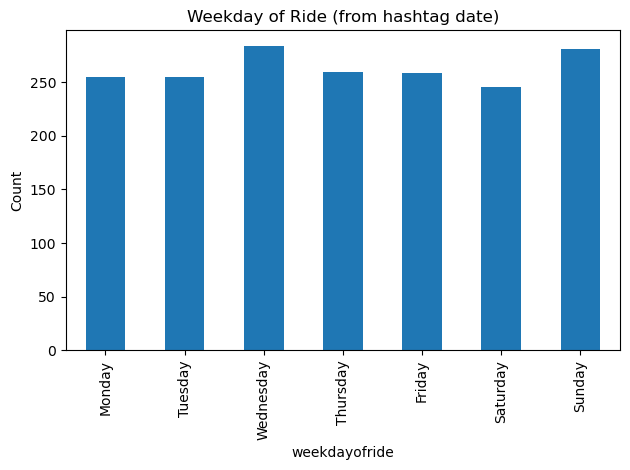

Saved figure: outputs\figures\weekday_of_ride.png


In [54]:
import matplotlib.pyplot as plt

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
wk = df2["weekdayofride"].value_counts().reindex(weekday_order)

ax = wk.plot(kind="bar")
plt.title("Weekday of Ride (from hashtag date)")
plt.ylabel("Count")
plt.tight_layout()

fig_path = FIG_DIR / "weekday_of_ride.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved figure:", fig_path)

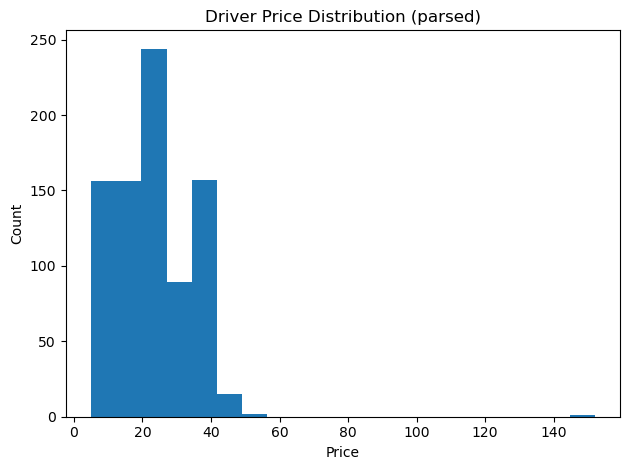

Saved figure: outputs\figures\driver_price_hist.png


In [55]:
drivers = df2[df2["rideordrive"] == 0].copy()
drivers = drivers[drivers["price"] > 0]

ax = drivers["price"].plot(kind="hist", bins=20)
plt.title("Driver Price Distribution (parsed)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()

fig_path = FIG_DIR / "driver_price_hist.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved figure:", fig_path)

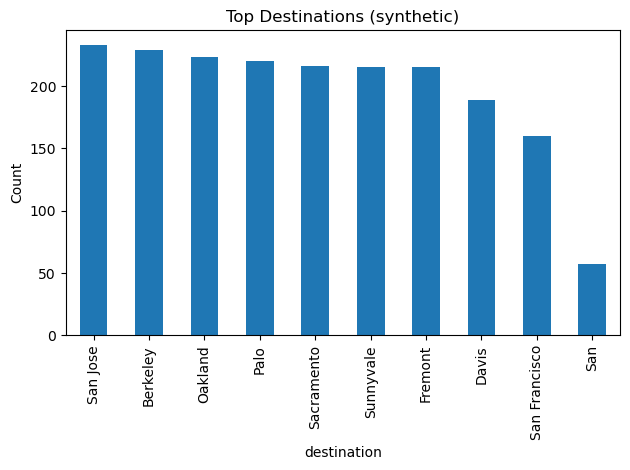

Saved figure: outputs\figures\top_destinations.png


In [56]:
import matplotlib.pyplot as plt

top_dest = df2["destination"].value_counts().head(10)
ax = top_dest.plot(kind="bar")
plt.title("Top Destinations (synthetic)")
plt.ylabel("Count")
plt.tight_layout()

fig_path = FIG_DIR / "top_destinations.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved figure:", fig_path)


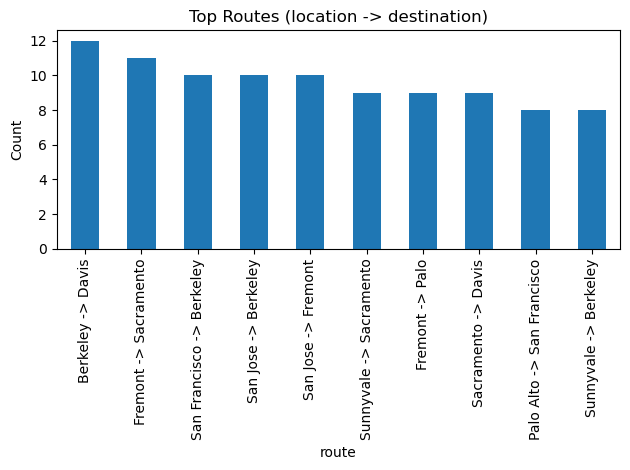

Saved figure: outputs\figures\top_routes.png


In [57]:
routes = df2.dropna(subset=["location", "destination"]).copy()
routes["route"] = routes["location"] + " -> " + routes["destination"]

top_routes = routes["route"].value_counts().head(10)
ax = top_routes.plot(kind="bar")
plt.title("Top Routes (location -> destination)")
plt.ylabel("Count")
plt.tight_layout()

fig_path = FIG_DIR / "top_routes.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved figure:", fig_path)


In [58]:
top_dest_df = top_dest.reset_index()
top_dest_df.columns = ["destination", "count"]
top_dest_path = TAB_DIR / "top_destinations.csv"
top_dest_df.to_csv(top_dest_path, index=False)
print("Saved table:", top_dest_path)

top_routes_df = top_routes.reset_index()
top_routes_df.columns = ["route", "count"]
top_routes_path = TAB_DIR / "top_routes.csv"
top_routes_df.to_csv(top_routes_path, index=False)
print("Saved table:", top_routes_path)


Saved table: outputs\tables\top_destinations.csv
Saved table: outputs\tables\top_routes.csv


In [59]:
print(df2.columns)

Index(['post_id', 'post_text', 'content', 'index', 'timeofposting',
       'rideordrive', 'dateofride', 'weekdayofride', 'price', 'location',
       'destination'],
      dtype='object')


In [60]:
print("Destination coverage:", df2["destination"].notna().mean())
df2[["location", "destination"]].value_counts().head(5)


Destination coverage: 0.9965


location       destination
Berkeley       Davis          12
Fremont        Sacramento     11
San Jose       Berkeley       10
San Francisco  Berkeley       10
San Jose       Fremont        10
Name: count, dtype: int64